In [1]:
# 02. Построение графовой структуры ветропарка

#Цель: Создать граф турбин на основе их пространственного расположения для последующего использования в GraphSAGE.

In [2]:
import torch
import torch_geometric
print("Torch version:", torch.__version__)
print("Torch Geometric version:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.11.0+cpu
Torch Geometric version: 2.7.0
CUDA available: False


In [3]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import cdist
import torch
from torch_geometric.data import Data
import seaborn as sns

plt.style.use('default')
%matplotlib inline

In [4]:
loc = pd.read_csv('../data/sdwpf_baidukddcup2022_turb_location.csv')

print(f"Загружено турбин: {len(loc)}")
display(loc.head())

Загружено турбин: 134


,TurbID,x,y
0,1,3349.8515,5939.23193
1,2,3351.0017,6416.64673
2,3,3314.7797,6892.18395
3,4,3352.0940,7366.14203
4,5,3355.3420,7841.20175


In [5]:
def build_knn_graph(location_df, k=6):
    """Построение k-NN графа"""
    coords = location_df[['x', 'y']].values
    dist_matrix = cdist(coords, coords)
    
   
    indices = np.argsort(dist_matrix, axis=1)[:, 1:k+1]
    

    row = np.repeat(np.arange(len(coords)), k)
    col = indices.flatten()
    
  
    edge_index = torch.tensor(np.stack([row, col]), dtype=torch.long)
    
    distances = dist_matrix[row, col]
    edge_weight = torch.tensor(1.0 / (distances + 1e-6), dtype=torch.float)
    
    print(f"Граф построен:")
    print(f"  Узлов: {len(coords)}")
    print(f"  Рёбер: {len(row)}")
    print(f"  Среднее расстояние между соседями: {distances.mean():.2f}")
    
    return edge_index, edge_weight, dist_matrix


edge_index, edge_weight, dist_matrix = build_knn_graph(loc, k=6)

Граф построен:
  Узлов: 134
  Рёбер: 804
  Среднее расстояние между соседями: 850.12


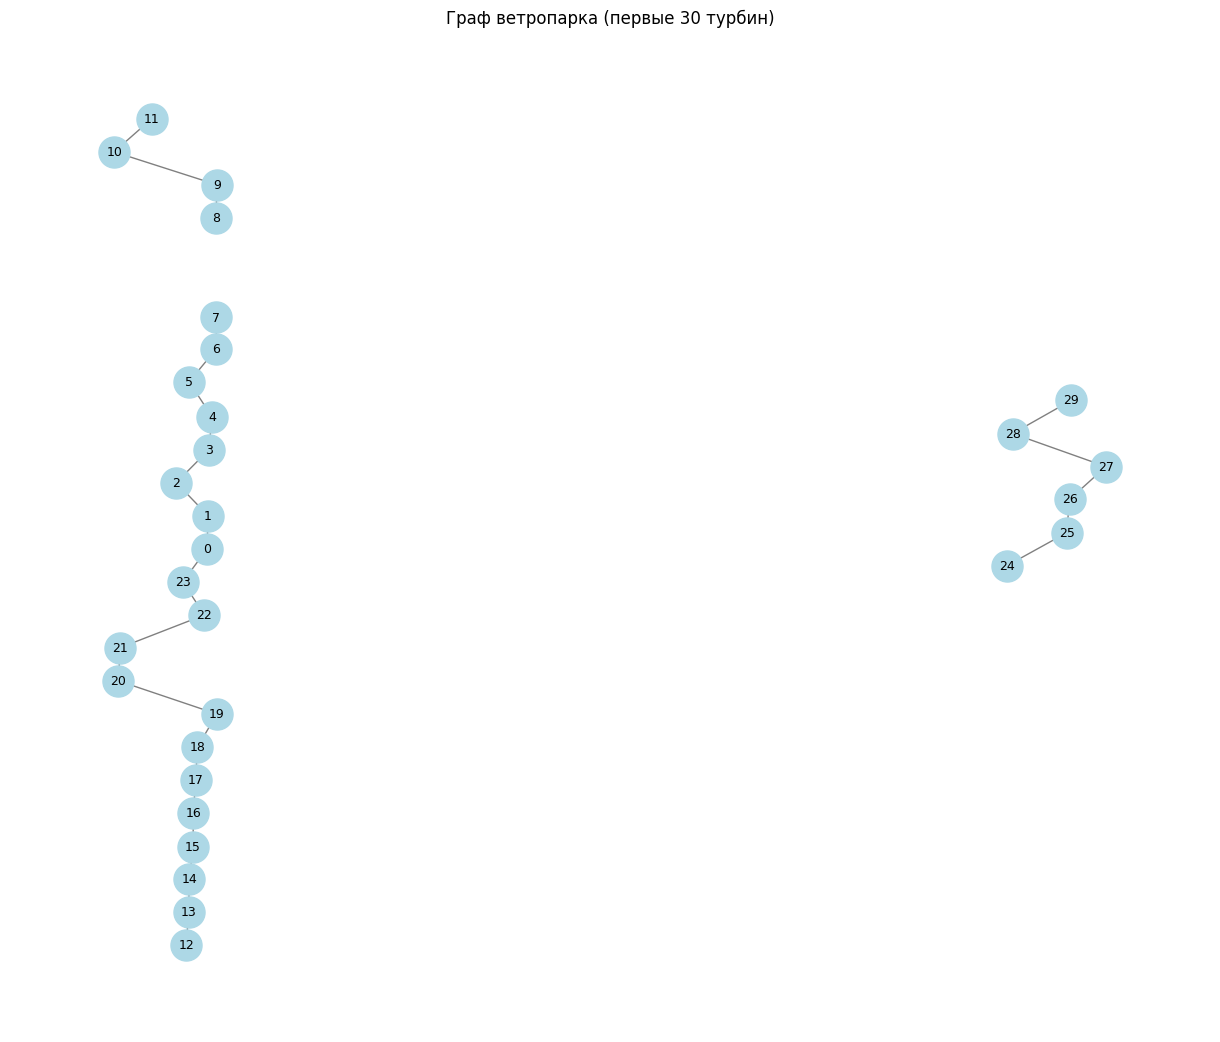

In [6]:

G = nx.Graph()
G.add_nodes_from(range(30))

for i in range(30):
    for j in range(i+1, 30):
        if dist_matrix[i,j] < 800:  # порог для визуализации
            G.add_edge(i, j)

plt.figure(figsize=(12, 10))
pos = {i: (loc.iloc[i]['x'], loc.iloc[i]['y']) for i in range(30)}

nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=9, edge_color='gray')
plt.title('Граф ветропарка (первые 30 турбин)')
plt.xlabel('Координата X')
plt.ylabel('Координата Y')
plt.grid(True)
plt.show()

In [7]:

graph_data = {
    'edge_index': edge_index,
    'edge_weight': edge_weight,
    'num_nodes': len(loc),
    'location': loc.to_dict()  
}

torch.save(graph_data, '../results/graph_data.pt')
print("Граф успешно сохранён (исправленная версия)")

Граф успешно сохранён (исправленная версия)
